<a href="https://colab.research.google.com/github/ashish-jumare/stock-movement-prediction/blob/main/DeBERTa_inference_on_headlines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#   Daily Sentiment Index from DeBERTa Model
## Run DeBERTa inference on headlines to Build daily NSE sentiment scores


##  Step 1: Setup & Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

# ── Paths ─────────────────────
# Where your trained DeBERTa checkpoint is saved
# Use whichever run gave your best result

POSSIBLE_MODEL_PATHS = [
    '/content/drive/MyDrive/sentfin_v6/models/model_best.pt',
]

# News sentiment CSV
NEWS_CSV = '/content/drive/MyDrive/dataset/News_sentiment_cleaned.csv'

# Output directory
OUT_DIR  = '/content/drive/MyDrive/phase4_sentiment'
os.makedirs(OUT_DIR, exist_ok=True)

# Find which model path exists
MODEL_PATH = None
for p in POSSIBLE_MODEL_PATHS:
    if os.path.exists(p):
        MODEL_PATH = p
        print(f'✅ Found model: {p}')
        break

if MODEL_PATH is None:
    print('  No model found automatically.')
    print('Please update POSSIBLE_MODEL_PATHS with the correct path')
    print('Or upload model manually in next cell')

print(f'✅ Output directory: {OUT_DIR}')

Mounted at /content/drive
✅ Found model: /content/drive/MyDrive/sentfin_v6/models/model_best.pt
✅ Output directory: /content/drive/MyDrive/phase4_sentiment


In [ ]:
%%capture
!pip install transformers==4.40.0
!pip install torch torchvision
!pip install pandas numpy matplotlib seaborn tqdm
!pip install sentencepiece
print('✅ Installed')

In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast

from transformers import AutoTokenizer, AutoModel

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')
print(f'✅ GPU   : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')


TRAINED_MODEL_NAME = 'microsoft/deberta-v3-base'
MAX_LEN     = 64
BATCH_SIZE  = 128
LEXICON_DIM = 14
LABEL2ID    = {'negative':0, 'neutral':1, 'positive':2}
ID2LABEL    = {v:k for k,v in LABEL2ID.items()}

print(f'✅ Model : {TRAINED_MODEL_NAME}')
print(f'✅ Config: MAX_LEN={MAX_LEN}, BATCH={BATCH_SIZE}, LEX_DIM={LEXICON_DIM}')

✅ Device: cuda
✅ GPU   : Tesla T4
✅ Model : microsoft/deberta-v3-base
✅ Config: MAX_LEN=64, BATCH=128, LEX_DIM=14


## 📂 Step 2: Load News Dataset

In [ ]:
# ── Load news data from verified path with Garbage Value Cleaning ──────────
import pandas as pd
import os
import re

def clean_garbage(text):
    # Remove encoding artifacts and non-ascii characters
    text = text.encode('ascii', 'ignore').decode('ascii')
    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

if os.path.exists(NEWS_CSV):
    df_news = pd.read_csv(NEWS_CSV, encoding='latin-1')
    print(f'✅ Loaded from Drive: {len(df_news):,} rows')
else:
    print(f' File not found at: {NEWS_CSV}')

if 'df_news' in locals() and not df_news.empty:
    df_news = df_news[['Date','Title']].copy()
    df_news.columns = ['date_str', 'headline']

    # Clean headlines from garbage characters
    print('🧹 Cleaning garbage characters from headlines...')
    df_news['headline'] = df_news['headline'].fillna('').astype(str).apply(clean_garbage)

    # Remove rows that became too short after cleaning
    df_news = df_news[df_news['headline'].str.len() > 5]

    # Flexible parsing with dayfirst=True
    df_news['date'] = pd.to_datetime(df_news['date_str'], dayfirst=True, errors='coerce')

    failed_count = df_news['date'].isna().sum()
    if failed_count > 0:
        print(f' Warning: {failed_count:,} rows failed date parsing.')

    df_news = df_news.dropna(subset=['date'])
    df_news = df_news.sort_values('date').reset_index(drop=True)

    if len(df_news) > 0:
        print(f'\nAfter cleaning: {len(df_news):,} rows')
        print(f'Date range: {df_news["date"].min().date()} to {df_news["date"].max().date()}')
        print('\nSample headlines (cleaned):')
        for h in df_news['headline'].head(5):
            print(f'  • {h}')

✅ Loaded from Drive: 200,288 rows
🧹 Cleaning garbage characters from headlines...

After cleaning: 198,730 rows
Date range: 2017-01-01 to 2021-04-15

Sample headlines (cleaned):
  • Your money in 2017 : Investment avenues
  • In 2016 , RBI actions changed the fortune of Indian rupee
  • NDA govt dedicated for welfare of poor : Rajnath Singh
  • Amit Shah welcomes lowering of interest rates by banks
  • 889 prosecuted for drunken driving on New Year eve


##  Step 3: Rebuild Exact Model Architecture


In [ ]:
# ── Lexicon features — matching dimensions from checkpoint ━━━━━━━━━━━━━━━━━━
POSITIVE_WORDS = ['profit','gain','rise','surge','rally','growth','strong','beats','outperform','record','high','best','upgrade','buy','accumulate','positive','upside','opportunity','recovery','robust','jump','expand','increase','improve','benefit','wins','soars','raises','appointment','dividend','acquisition','addition']
NEGATIVE_WORDS = ['loss','fall','decline','drop','crash','weak','miss','cut','underperform','concern','low','worst','downgrade','sell','avoid','negative','downside','risk','crisis','slump','plunge','fraud','contract','decrease','worsen','hurt','warn','penalty','charge','default','bankrupt','suspend','probe','investigation','exits']
DIRECTIONAL_UP   = ['up','rises','gains','rallies','surges','jumps','climbs','advances','soars','increases','uptrend']
DIRECTIONAL_DOWN = ['down','falls','drops','declines','slides','slumps','tumbles','dips','retreats','decreases','downtrend']
NEGATION_WORDS   = ['not','no','never','neither','nor','without','unable','fails','lack','despite','against']
UNCERTAINTY_WORDS= ['could','may','might','possibly','likely','unlikely','expected','forecast','estimate','outlook']

def extract_lexicon_features(text):
    words  = set(text.lower().split())
    words.discard('target'); words.discard('other')
    n_pos   = sum(1 for w in POSITIVE_WORDS    if w in words)
    n_neg   = sum(1 for w in NEGATIVE_WORDS    if w in words)
    n_dir_u = sum(1 for w in DIRECTIONAL_UP    if w in words)
    n_dir_d = sum(1 for w in DIRECTIONAL_DOWN  if w in words)
    n_neg_w = sum(1 for w in NEGATION_WORDS    if w in words)
    n_unc   = sum(1 for w in UNCERTAINTY_WORDS if w in words)
    wc      = len(text.split())
    return [
        n_pos, n_neg, n_dir_u, n_dir_d, n_neg_w, n_unc,
        n_pos - n_neg, n_dir_u - n_dir_d,
        float(n_neg_w>0), float(n_unc>0),
        wc, n_pos/max(wc,1), n_neg/max(wc,1),
        float((n_pos+n_neg+n_dir_u+n_dir_d)>0)

    ]

class DeBERTaLexiconFusion(nn.Module):
    def __init__(self, model_name=TRAINED_MODEL_NAME, lexicon_dim=LEXICON_DIM, num_classes=3, dropout=0.2):
        super().__init__()
        self.deberta    = AutoModel.from_pretrained(model_name)
        hidden          = self.deberta.config.hidden_size
        pool_dim        = hidden * 2
        self.lex_proj   = nn.Sequential(nn.Linear(lexicon_dim, 64), nn.LayerNorm(64), nn.GELU(), nn.Dropout(dropout))
        self.gate       = nn.Sequential(nn.Linear(pool_dim + 64, 1), nn.Sigmoid())
        self.lex_expand = nn.Linear(64, pool_dim)
        self.pool_norm  = nn.LayerNorm(pool_dim)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Sequential(nn.Linear(pool_dim, 256), nn.GELU(), nn.Dropout(dropout), nn.Linear(256, num_classes))

    def mean_pool(self, emb, mask):
        m = mask.unsqueeze(-1).float()
        return (emb*m).sum(1) / m.sum(1).clamp(min=1e-9)

    def forward(self, input_ids, attention_mask, lex_feats):
        out     = self.deberta(input_ids=input_ids, attention_mask=attention_mask)
        seq     = out.last_hidden_state
        cls_out = seq[:,0,:]
        mean_out= self.mean_pool(seq, attention_mask)
        neural  = torch.cat([cls_out, mean_out], dim=1)
        neural  = self.pool_norm(neural)
        neural  = self.dropout(neural)
        lex_64  = self.lex_proj(lex_feats)
        lex_exp = self.lex_expand(lex_64)
        alpha   = self.gate(torch.cat([neural, lex_64], dim=1))
        fused   = alpha*neural + (1-alpha)*lex_exp
        return self.classifier(fused), alpha

In [ ]:
# ── Load trained weights ────────────────────────────────────────────────────
# Option A: Automatic (if MODEL_PATH found above)
# Option B: Manual upload

if MODEL_PATH is None:
    print('Upload your trained model checkpoint (.pt file)')
    from google.colab import files
    uploaded   = files.upload()
    MODEL_PATH = list(uploaded.keys())[0]

print(f'Loading model from: {MODEL_PATH}')
# Initialize model with updated LEXICON_DIM=14 and pool_norm
model = DeBERTaLexiconFusion().to(DEVICE)
state = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state)
model.eval()

print(f'✅ Model loaded successfully')
total_params = sum(p.numel() for p in model.parameters())
print(f'   Total parameters: {total_params/1e6:.1f}M')

# Load tokenizer
print(f'\nLoading tokenizer: {TRAINED_MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(TRAINED_MODEL_NAME)
print('✅ Tokenizer loaded')

Loading model from: /content/drive/MyDrive/sentfin_v6/models/model_best.pt
✅ Model loaded successfully
   Total parameters: 184.3M

Loading tokenizer: microsoft/deberta-v3-base
✅ Tokenizer loaded


##  Step 4: Batch Inference on Headlines

In [ ]:
class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, texts):
        self.texts = texts
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        enc  = tokenizer(
            text, max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt')
        lex  = torch.tensor(
            extract_lexicon_features(text),
            dtype=torch.float)
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'lex_feats'     : lex
        }

# Estimate time
n_batches = len(df_news) // BATCH_SIZE + 1
est_min   = n_batches * 2.5 / 60  # ~2.5 sec/batch on T4
print(f'Total headlines : {len(df_news):,}')
print(f'Batch size      : {BATCH_SIZE}')
print(f'Total batches   : {n_batches:,}')
print(f'Estimated time  : {est_min:.0f}–{est_min*1.5:.0f} minutes on T4')
print()
print('Inference labels:')
print('  0 = Negative  1 = Neutral  2 = Positive')
print('NOTE: Existing CSV has NO neutral class — this is our improvement')

Total headlines : 198,730
Batch size      : 128
Total batches   : 1,553
Estimated time  : 65–97 minutes on T4

Inference labels:
  0 = Negative  1 = Neutral  2 = Positive
NOTE: Existing CSV has NO neutral class — this is our improvement


In [ ]:
# ── Run inference with alignment check ──────────────────────────────────────
CHECKPOINT_EVERY = 10000
CHECKPOINT_FILE  = f'{OUT_DIR}/inference_checkpoint.npz'

# Resume from checkpoint ONLY if it matches the current cleaned dataframe length
start_idx = 0
all_probs  = []
all_labels = []

if os.path.exists(CHECKPOINT_FILE):
    ckpt = np.load(CHECKPOINT_FILE, allow_pickle=True)
    temp_labels = list(ckpt['labels'])

    # Safety Check: If checkpoint is longer than our cleaned df, it's stale
    if len(temp_labels) > len(df_news):
        print(" Checkpoint is stale (from before garbage cleaning). Starting fresh...")
        if os.path.exists(CHECKPOINT_FILE): os.remove(CHECKPOINT_FILE)
    else:
        all_probs  = list(ckpt['probs'])
        all_labels = temp_labels
        start_idx  = len(all_labels)
        print(f'✅ Resuming from checkpoint: {start_idx:,} done, {len(df_news)-start_idx:,} remaining')

# Subset remaining
df_remaining = df_news.iloc[start_idx:].reset_index(drop=True)

if len(df_remaining) > 0:
    dataset = NewsDataset(df_remaining['headline'].tolist())
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model.eval()
    batch_probs  = []
    batch_labels = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(loader, desc='Running DeBERTa inference')):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lex  = batch['lex_feats'].to(DEVICE)

            with autocast():
                logits, _ = model(ids, mask, lex)

            probs = F.softmax(logits, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)

            batch_probs.extend(probs.tolist())
            batch_labels.extend(preds.tolist())

            # Save checkpoint
            processed = (batch_idx+1) * BATCH_SIZE
            if processed % CHECKPOINT_EVERY == 0:
                np.savez(CHECKPOINT_FILE,
                         probs=np.array(all_probs + batch_probs),
                         labels=np.array(all_labels + batch_labels))

    all_probs  = all_probs + batch_probs
    all_labels = all_labels + batch_labels
    np.savez(CHECKPOINT_FILE, probs=np.array(all_probs), labels=np.array(all_labels))

print(f'\n✅ Inference ready: {len(all_labels):,} predictions for {len(df_news):,} headlines.')

Running DeBERTa inference: 100%|██████████| 1553/1553 [04:18<00:00,  6.01it/s]



✅ Inference ready: 198,730 predictions for 198,730 headlines.


##  Step 5: Attach Predictions to Dataset

In [ ]:
# Add predictions to dataframe
probs_arr = np.array(all_probs)

df_pred = df_news.copy()
df_pred['pred_label']    = [ID2LABEL[l] for l in all_labels]
df_pred['prob_negative'] = probs_arr[:, 0]
df_pred['prob_neutral']  = probs_arr[:, 1]
df_pred['prob_positive'] = probs_arr[:, 2]
df_pred['confidence']    = probs_arr.max(axis=1)  # max prob = confidence

# Sentiment score: +1 × P(pos) - 1 × P(neg)  (range: -1 to +1)
df_pred['sentiment_score'] = (
    df_pred['prob_positive'] - df_pred['prob_negative'])

print('✅ Predictions attached')
print()
print('Prediction distribution (3 classes):')
print(df_pred['pred_label'].value_counts())
print()
print('Confidence stats:')
print(df_pred['confidence'].describe().round(3))
print()
print('Sentiment score stats:')
print(df_pred['sentiment_score'].describe().round(3))
print()
print('Sample predictions:')
print(df_pred[['headline','pred_label',
               'prob_positive','prob_neutral',
               'prob_negative','sentiment_score']].head(10).to_string())

# Save full predictions
df_pred.to_csv(f'{OUT_DIR}/all_headlines_with_predictions.csv',
               index=False)
print(f'\n✅ Saved: all_headlines_with_predictions.csv')

✅ Predictions attached

Prediction distribution (3 classes):
pred_label
neutral     81207
negative    59782
positive    57741
Name: count, dtype: int64

Confidence stats:
count    198730.000
mean          0.690
std           0.164
min           0.334
25%           0.557
50%           0.657
75%           0.863
max           0.973
Name: confidence, dtype: float64

Sentiment score stats:
count    198730.000
mean         -0.057
std           0.561
min          -0.950
25%          -0.487
50%          -0.114
75%           0.373
max           0.958
Name: sentiment_score, dtype: float64

Sample predictions:
                                                                    headline pred_label  prob_positive  prob_neutral  prob_negative  sentiment_score
0                                    Your money in 2017 : Investment avenues    neutral       0.078979      0.609863       0.311035        -0.232056
1                  In 2016 , RBI actions changed the fortune of Indian rupee    neutral       0

##  Step 6: Build Daily Sentiment Index


In [ ]:
def compute_daily_index(df):
    """
    Compute daily sentiment indices.
    Replicates SEntFiN paper Section 5 formulas EXACTLY
    so our work is directly comparable to their economic analysis.

    s1 = (Pos - Neg) / (Pos + Neg)         [paper's primary measure]
    s2 = (Pos - Neg) / (Pos + Neu + Neg)   [paper's alternate measure]
    s3 = mean(sentiment_score)             [our addition: probability-weighted]
    s4 = confidence-weighted sentiment     [our addition: high-confidence only]
    """
    daily_rows = []

    for date, group in df.groupby('date'):
        n_pos = (group['pred_label'] == 'positive').sum()
        n_neg = (group['pred_label'] == 'negative').sum()
        n_neu = (group['pred_label'] == 'neutral').sum()
        total = len(group)

        # SEntFiN paper formulas
        s1 = (n_pos-n_neg)/(n_pos+n_neg) if (n_pos+n_neg) > 0 else 0
        s2 = (n_pos-n_neg)/total          if total > 0           else 0

        # Our improvements
        s3 = group['sentiment_score'].mean()  # prob-weighted

        # Confidence-weighted: only use predictions model is sure about
        high_conf = group[group['confidence'] >= 0.7]
        if len(high_conf) > 0:
            hc_pos = (high_conf['pred_label']=='positive').sum()
            hc_neg = (high_conf['pred_label']=='negative').sum()
            hc_tot = len(high_conf)
            s4 = (hc_pos-hc_neg)/hc_tot if hc_tot > 0 else 0
        else:
            s4 = 0

        daily_rows.append({
            'date'             : date,
            # Counts
            'n_positive'       : int(n_pos),
            'n_negative'       : int(n_neg),
            'n_neutral'        : int(n_neu),
            'n_total'          : int(total),
            'neutral_ratio'    : round(n_neu/total, 4) if total>0 else 0,
            # Sentiment indices
            's1_primary'       : round(s1, 6),   # paper formula 1
            's2_alternate'     : round(s2, 6),   # paper formula 2
            's3_prob_weighted' : round(s3, 6),   # our addition
            's4_conf_weighted' : round(s4, 6),   # our addition
            # Statistics
            'avg_confidence'   : round(group['confidence'].mean(), 4),
            'avg_pos_prob'     : round(group['prob_positive'].mean(), 4),
            'avg_neg_prob'     : round(group['prob_negative'].mean(), 4),
            'avg_neu_prob'     : round(group['prob_neutral'].mean(),  4),
        })

    daily_df = pd.DataFrame(daily_rows).sort_values('date')
    return daily_df

print('Computing daily sentiment indices...')
daily_df = compute_daily_index(df_pred)

print(f'\n✅ Daily sentiment index built')
print(f'   Total trading days: {len(daily_df):,}')
print(f'   Date range: {daily_df["date"].min().date()} → '
      f'{daily_df["date"].max().date()}')
print()
print('Sample daily index:')
print(daily_df[['date','n_positive','n_negative','n_neutral',
                'neutral_ratio','s1_primary','s2_alternate',
                's3_prob_weighted']].head(10).to_string())
print()
print('Index statistics:')
print(daily_df[['s1_primary','s2_alternate',
                's3_prob_weighted','s4_conf_weighted']].describe().round(4))

# Save
daily_df.to_csv(f'{OUT_DIR}/daily_sentiment_index.csv', index=False)
print(f'\n✅ Saved: daily_sentiment_index.csv')

Computing daily sentiment indices...

✅ Daily sentiment index built
   Total trading days: 1,554
   Date range: 2017-01-01 → 2021-04-15

Sample daily index:
        date  n_positive  n_negative  n_neutral  neutral_ratio  s1_primary  s2_alternate  s3_prob_weighted
0 2017-01-01           8           7         21         0.5833    0.066667      0.027778         -0.078972
1 2017-01-02          15          23         39         0.5065   -0.210526     -0.103896         -0.153678
2 2017-01-03          54          24         56         0.4179    0.384615      0.223881          0.134666
3 2017-01-04          39          37         81         0.5159    0.026316      0.012739         -0.046237
4 2017-01-05          55          43         61         0.3836    0.122449      0.075472          0.016076
5 2017-01-06          18          23         30         0.4225   -0.121951     -0.070423         -0.121522
6 2017-01-07          15          17         29         0.4754   -0.062500     -0.032787      

## Step 7: Analysis Plots for Paper

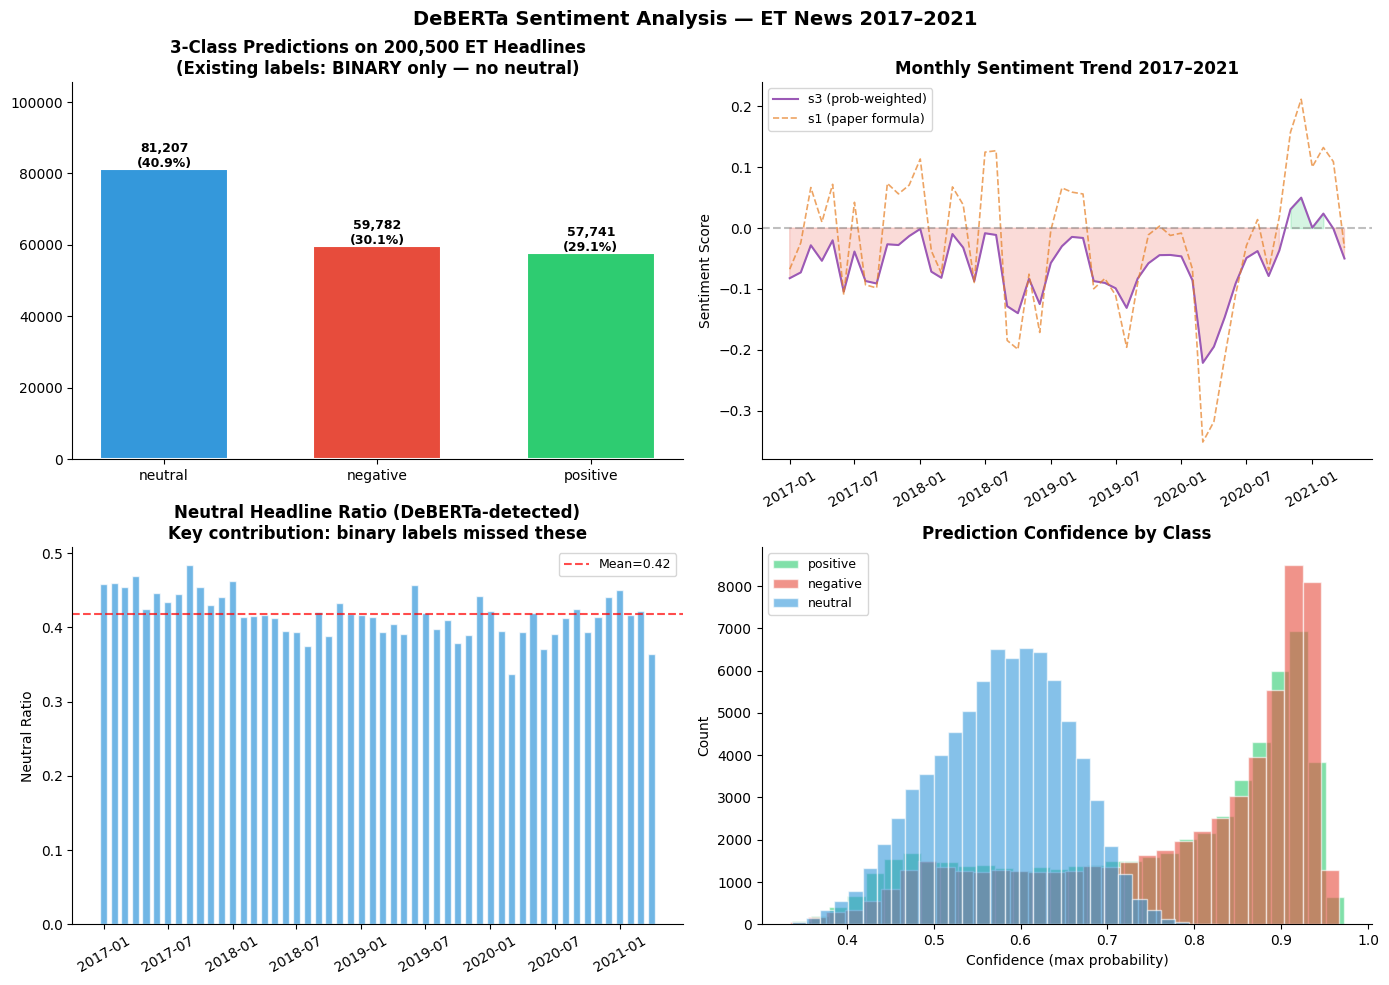

✅ Saved: sentiment_analysis_plots.png (300 DPI — ready for paper)


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'DeBERTa Sentiment Analysis — ET News 2017–2021',
    fontsize=14, fontweight='bold')

COLORS = {'positive':'#2ecc71','negative':'#e74c3c','neutral':'#3498db'}

# 1. Prediction distribution (3-class)
counts = df_pred['pred_label'].value_counts()
bars = axes[0,0].bar(
    counts.index, counts.values,
    color=[COLORS[c] for c in counts.index],
    edgecolor='white', linewidth=1.5, width=0.6)
for b, v in zip(bars, counts.values):
    axes[0,0].text(
        b.get_x()+b.get_width()/2,
        b.get_height()+500,
        f'{v:,}\n({v/len(df_pred)*100:.1f}%)',
        ha='center', fontsize=9, fontweight='bold')
axes[0,0].set_title(
    '3-Class Predictions on 200,500 ET Headlines\n'
    '(Existing labels: BINARY only — no neutral)',
    fontweight='bold')
axes[0,0].set_ylim(0, counts.max()*1.3)
axes[0,0].spines[['top','right']].set_visible(False)

# 2. Monthly sentiment trend (s3 prob-weighted)
daily_df['year_month'] = daily_df['date'].dt.to_period('M')
monthly = daily_df.groupby('year_month').agg(
    s3=('s3_prob_weighted','mean'),
    s1=('s1_primary','mean')
).reset_index()
monthly['period'] = monthly['year_month'].dt.to_timestamp()

axes[0,1].plot(monthly['period'], monthly['s3'],
               color='#9b59b6', linewidth=1.5,
               label='s3 (prob-weighted)')
axes[0,1].plot(monthly['period'], monthly['s1'],
               color='#e67e22', linewidth=1.2, alpha=0.7,
               linestyle='--', label='s1 (paper formula)')
axes[0,1].axhline(0, color='gray', ls='--', alpha=0.5)
axes[0,1].fill_between(
    monthly['period'], monthly['s3'],
    where=monthly['s3'] > 0, alpha=0.2, color='#2ecc71')
axes[0,1].fill_between(
    monthly['period'], monthly['s3'],
    where=monthly['s3'] < 0, alpha=0.2, color='#e74c3c')
axes[0,1].set_title(
    'Monthly Sentiment Trend 2017–2021',
    fontweight='bold')
axes[0,1].legend(fontsize=9)
axes[0,1].set_ylabel('Sentiment Score')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].spines[['top','right']].set_visible(False)

# 3. Neutral ratio over time
monthly_neu = daily_df.groupby('year_month')[
    'neutral_ratio'].mean().reset_index()
monthly_neu['period'] = monthly_neu['year_month'].dt.to_timestamp()
axes[1,0].bar(
    monthly_neu['period'], monthly_neu['neutral_ratio'],
    color='#3498db', alpha=0.7,
    width=20, edgecolor='white')
axes[1,0].axhline(
    daily_df['neutral_ratio'].mean(),
    color='red', ls='--', alpha=0.7,
    label=f'Mean={daily_df["neutral_ratio"].mean():.2f}')
axes[1,0].set_title(
    'Neutral Headline Ratio (DeBERTa-detected)\n'
    'Key contribution: binary labels missed these',
    fontweight='bold')
axes[1,0].set_ylabel('Neutral Ratio')
axes[1,0].legend(fontsize=9)
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].spines[['top','right']].set_visible(False)

# 4. Confidence distribution by class
for label, color in COLORS.items():
    subset = df_pred[df_pred['pred_label']==label]['confidence']
    axes[1,1].hist(
        subset, bins=30, alpha=0.6,
        color=color, label=label,
        edgecolor='white')
axes[1,1].set_title(
    'Prediction Confidence by Class',
    fontweight='bold')
axes[1,1].set_xlabel('Confidence (max probability)')
axes[1,1].set_ylabel('Count')
axes[1,1].legend(fontsize=9)
axes[1,1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/sentiment_analysis_plots.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('✅ Saved: sentiment_analysis_plots.png (300 DPI — ready for paper)')

##  Step 8: Compare DeBERTa vs Existing Binary Labels

Correlation between binary labels and DeBERTa indices:
  s1_binary ↔ s1_primary   : 0.0882
  s2_binary ↔ s2_alternate  : 0.0915
  s2_binary ↔ s3_prob_weighted: 0.0950


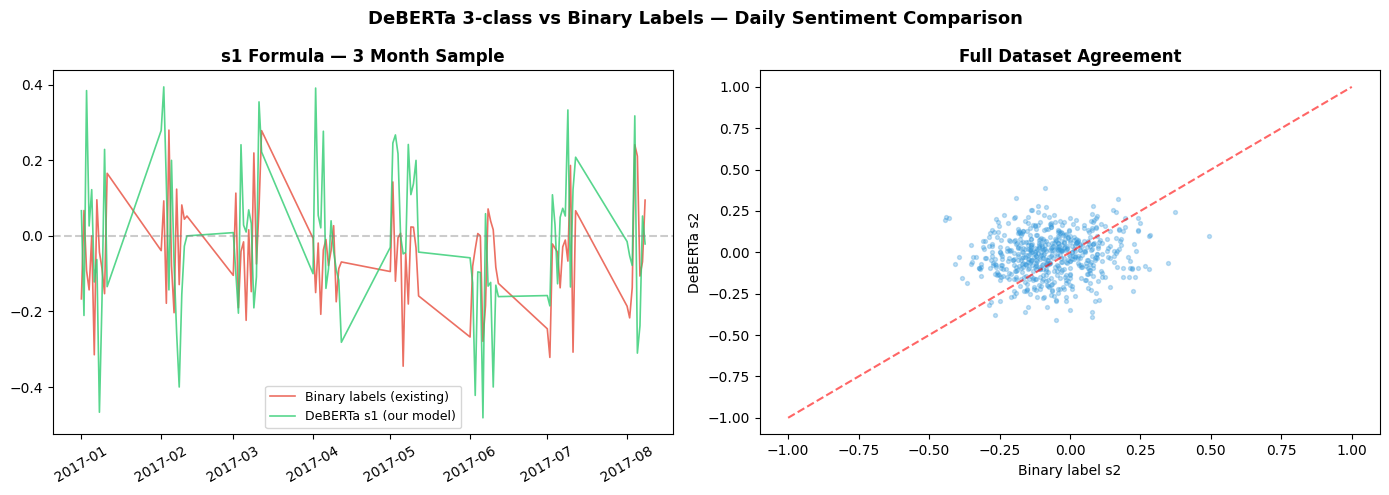

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Load original data
original_df = pd.read_csv(NEWS_CSV, encoding='latin-1')
original_df = original_df[['Date','Title','sentiment','confidence']].copy()

# Use flexible date parsing to match the earlier successful cleaning
original_df['date'] = pd.to_datetime(original_df['Date'], errors='coerce')
original_df = original_df.dropna(subset=['date'])

# Daily sentiment from original binary labels
def daily_binary(df):
    rows = []
    if df.empty:
        return pd.DataFrame(columns=['date', 's1_binary', 's2_binary'])

    for date, g in df.groupby('date'):
        # Standardizing labels to uppercase for comparison
        pos = (g['sentiment'].astype(str).str.upper() == 'POSITIVE').sum()
        neg = (g['sentiment'].astype(str).str.upper() == 'NEGATIVE').sum()
        tot = len(g)
        rows.append({
            'date': date,
            's1_binary': (pos-neg)/(pos+neg) if (pos+neg)>0 else 0,
            's2_binary': (pos-neg)/tot       if tot>0       else 0,
        })
    return pd.DataFrame(rows).sort_values('date')

daily_binary_df = daily_binary(original_df)

# Merge for comparison
compare = pd.merge(
    daily_df[['date','s1_primary','s2_alternate','s3_prob_weighted']],
    daily_binary_df,
    on='date', how='inner')

print('Correlation between binary labels and DeBERTa indices:')
if not compare.empty:
    print(f'  s1_binary ↔ s1_primary   : {compare["s1_binary"].corr(compare["s1_primary"]):.4f}')
    print(f'  s2_binary ↔ s2_alternate  : {compare["s2_binary"].corr(compare["s2_alternate"]):.4f}')
    print(f'  s2_binary ↔ s3_prob_weighted: {compare["s2_binary"].corr(compare["s3_prob_weighted"]):.4f}')

    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('DeBERTa 3-class vs Binary Labels — Daily Sentiment Comparison', fontsize=13, fontweight='bold')

    sample = compare.iloc[:90] # 3 Month Sample
    dates = sample['date']
    axes[0].plot(dates, sample['s1_binary'], label='Binary labels (existing)', color='#e74c3c', alpha=0.8, linewidth=1.2)
    axes[0].plot(dates, sample['s1_primary'], label='DeBERTa s1 (our model)', color='#2ecc71', alpha=0.8, linewidth=1.2)
    axes[0].axhline(0, color='gray', ls='--', alpha=0.4)
    axes[0].set_title('s1 Formula — 3 Month Sample', fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].tick_params(axis='x', rotation=30)

    axes[1].scatter(compare['s2_binary'], compare['s2_alternate'], alpha=0.3, s=8, color='#3498db')
    axes[1].plot([-1,1], [-1,1], 'r--', alpha=0.6, label='Perfect agreement')
    axes[1].set_xlabel('Binary label s2')
    axes[1].set_ylabel('DeBERTa s2')
    axes[1].set_title('Full Dataset Agreement', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/deberta_vs_binary_comparison.png', dpi=300)
    plt.show()
else:
    print('  No overlapping dates found for correlation after cleaning.')

##  Step 9: Save Everything + Summary

In [ ]:
# Save final summary stats for paper
summary = {
    'model_used'         : TRAINED_MODEL_NAME,
    'total_headlines'    : int(len(df_pred)),
    'date_range'         : {
        'start': str(df_pred['date'].min().date()),
        'end'  : str(df_pred['date'].max().date())
    },
    'prediction_distribution': {
        'positive': int((df_pred['pred_label']=='positive').sum()),
        'negative': int((df_pred['pred_label']=='negative').sum()),
        'neutral' : int((df_pred['pred_label']=='neutral').sum()),
    },
    'neutral_percentage' : round(
        (df_pred['pred_label']=='neutral').mean()*100, 2),
    'avg_daily_articles' : round(
        len(df_pred)/daily_df['date'].nunique(), 1),
    'trading_days'       : int(len(daily_df)),
    'sentiment_index_stats': {
        's1_mean'  : round(daily_df['s1_primary'].mean(), 4),
        's1_std'   : round(daily_df['s1_primary'].std(),  4),
        's2_mean'  : round(daily_df['s2_alternate'].mean(), 4),
        's3_mean'  : round(daily_df['s3_prob_weighted'].mean(), 4),
    },
    'improvement_over_binary': {
        'binary_labels_classes' : 2,
        'deberta_classes'       : 3,
        'neutral_headlines_added': int(
            (df_pred['pred_label']=='neutral').sum()),
        'key_insight': ('SEntFiN paper proves neutral sentiment '
                        'ATTENUATES market movement (s2 formula). '
                        'Binary labels cannot capture this. '
                        'DeBERTa 3-class enables richer economic signal.')
    }
}

with open(f'{OUT_DIR}/phase3_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('='*60)
print('✅ PHASE 3 COMPLETE — Files saved to Drive')
print('='*60)
print(f'\n📁 {OUT_DIR}/')
print('   all_headlines_with_predictions.csv  (200k rows + 3-class probs)')
print('   daily_sentiment_index.csv           (1,554 days × 8 columns)')
print('   inference_checkpoint.npz            (checkpoint backup)')
print('   sentiment_analysis_plots.png        (Figure 3 for paper)')
print('   deberta_vs_binary_comparison.png    (Figure 4 for paper)')
print('   phase3_summary.json                 (stats for paper writing)')
print()
print('📊 KEY NUMBERS FOR YOUR PAPER:')
print(f'   Total headlines analyzed   : {summary["total_headlines"]:,}')
print(f'   Neutral headlines detected : {summary["prediction_distribution"]["neutral"]:,} '
      f'({summary["neutral_percentage"]}%)')
print(f'   Trading days covered       : {summary["trading_days"]}')
print(f'   Mean daily sentiment (s1)  : {summary["sentiment_index_stats"]["s1_mean"]}')
print()
print('📌 NEXT STEP: Run Phase 4 notebook')
print('   → Download NSE 500 prices')
print('   → Merge with daily_sentiment_index.csv')
print('   → Train market direction predictor')

✅ PHASE 3 COMPLETE — Files saved to Drive

📁 /content/drive/MyDrive/phase4_sentiment/
   all_headlines_with_predictions.csv  (200k rows + 3-class probs)
   daily_sentiment_index.csv           (1,554 days × 8 columns)
   inference_checkpoint.npz            (checkpoint backup)
   sentiment_analysis_plots.png        (Figure 3 for paper)
   deberta_vs_binary_comparison.png    (Figure 4 for paper)
   phase3_summary.json                 (stats for paper writing)

📊 KEY NUMBERS FOR YOUR PAPER:
   Total headlines analyzed   : 198,730
   Neutral headlines detected : 81,207 (40.86%)
   Trading days covered       : 1554
   Mean daily sentiment (s1)  : -0.0235

📌 NEXT STEP: Run Phase 4 notebook
   → Download NSE 500 prices
   → Merge with daily_sentiment_index.csv
   → Train market direction predictor


📁 Contents of /content/drive/MyDrive/phase4_sentiment:
  - all_headlines_with_predictions.csv
  - daily_sentiment_index.csv
  - sentiment_analysis_plots.png
  - deberta_vs_binary_comparison.png
  - phase3_summary.json
  - all_headlines_with_predictions.gsheet
  - all_headlines_with_predictions (1).gsheet
  - inference_checkpoint.npz

✅ Found 1554 days.


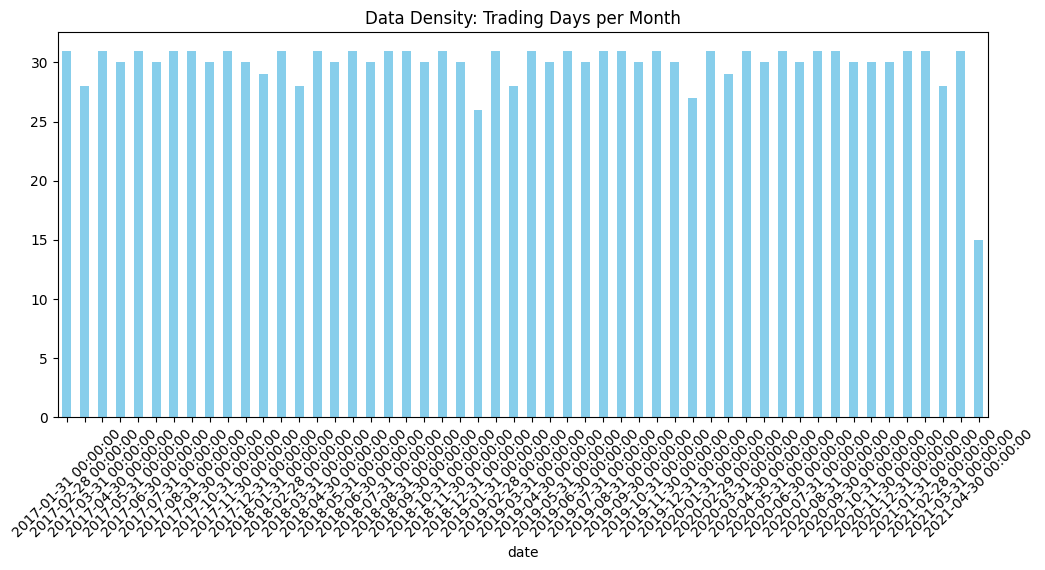

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Let's verify what files actually exist in your Drive folder
DRIVE_DIR = '/content/drive/MyDrive/phase4_sentiment'

if os.path.exists(DRIVE_DIR):
    print(f'📁 Contents of {DRIVE_DIR}:')
    files = os.listdir(DRIVE_DIR)
    for f in files:
        print(f'  - {f}')

    FILE_NAME = 'daily_sentiment_index.csv'
    FULL_PATH = os.path.join(DRIVE_DIR, FILE_NAME)

    if FILE_NAME in files:
        df_final_sentiment = pd.read_csv(FULL_PATH)
        df_final_sentiment['date'] = pd.to_datetime(df_final_sentiment['date'])

        print(f'\n✅ Found {len(df_final_sentiment)} days.')

        # Plot the density
        plt.figure(figsize=(12, 5))
        df_final_sentiment.set_index('date').resample('M').size().plot(kind='bar', color='skyblue')
        plt.title('Data Density: Trading Days per Month')
        plt.xticks(rotation=45)
        plt.show()
    else:
        print(f'\n {FILE_NAME} is missing. Please re-run the inference cell (P9-nfQpfExlj).')
else:
    print(f' Folder {DRIVE_DIR} does not exist. Please check your Drive mount.')